In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
n_legit = 1400

legit = pd.DataFrame({
    'plate_valid':    np.random.choice([1, 1, 1, 0], size=n_legit),  # mostly valid
    'match_score':    np.random.uniform(0.55, 1.0, size=n_legit),
    'num_detected':   np.random.randint(1, 5, size=n_legit),
    'claim_amount':   np.random.randint(5000, 120000, size=n_legit),
    'vehicle_age':    np.random.randint(1, 10, size=n_legit),
    'fraud_label':    0
})

# num_claimed is close to num_detected for legit
legit['num_claimed'] = legit['num_detected'] + np.random.choice([0, 0, 0, 1, -1], size=n_legit)
legit['num_claimed'] = legit['num_claimed'].clip(1, 6)

In [3]:
n_fraud = 600

fraud = pd.DataFrame({
    'plate_valid':    np.random.choice([0, 0, 1], size=n_fraud),  # mostly invalid
    'match_score':    np.random.uniform(0.0, 0.35, size=n_fraud),  # low match
    'num_detected':   np.random.randint(1, 3, size=n_fraud),
    'claim_amount':   np.random.randint(150000, 500000, size=n_fraud),  # inflated
    'vehicle_age':    np.random.randint(8, 20, size=n_fraud),  # old vehicle
    'fraud_label':    1
})

# num_claimed is much higher than detected for fraud
fraud['num_claimed'] = fraud['num_detected'] + np.random.randint(2, 5, size=n_fraud)
fraud['num_claimed'] = fraud['num_claimed'].clip(1, 6)

In [4]:
df = pd.concat([legit, fraud], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Add 10% noise — flip some fraud labels to simulate real world messiness
noise_idx = df.sample(frac=0.10, random_state=7).index
df.loc[noise_idx, 'fraud_label'] = 1 - df.loc[noise_idx, 'fraud_label']

# Final column order
df = df[['plate_valid', 'match_score', 'num_detected', 'num_claimed', 'claim_amount', 'vehicle_age', 'fraud_label']]

print(df.shape)
print(df['fraud_label'].value_counts())
print(df.isnull().sum())
df.head()

(2000, 7)
fraud_label
0    1318
1     682
Name: count, dtype: int64
plate_valid     0
match_score     0
num_detected    0
num_claimed     0
claim_amount    0
vehicle_age     0
fraud_label     0
dtype: int64


,plate_valid,match_score,num_detected,num_claimed,claim_amount,vehicle_age,fraud_label
0,1,0.018225,2,4,264310,11,1
1,0,0.909452,1,1,63002,6,0
2,0,0.987402,2,2,64287,7,1
3,1,0.783577,1,1,98305,7,0
4,1,0.878279,1,1,105246,6,0


In [5]:
df.to_csv('fraud_dataset.csv', index=False)
print("Saved!")

Saved!


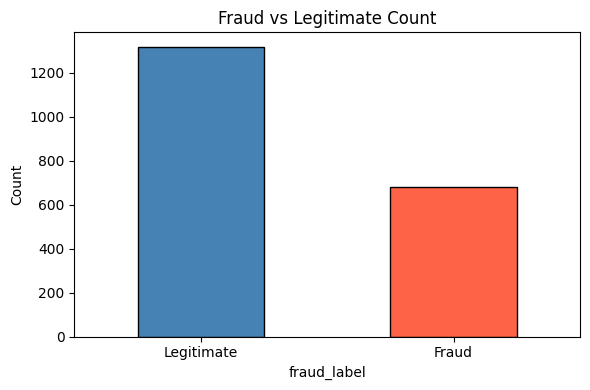

In [6]:
plt.figure(figsize=(6,4))
df['fraud_label'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.xticks([0,1], ['Legitimate', 'Fraud'], rotation=0)
plt.title('Fraud vs Legitimate Count')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_fraud_count.png')
plt.show()

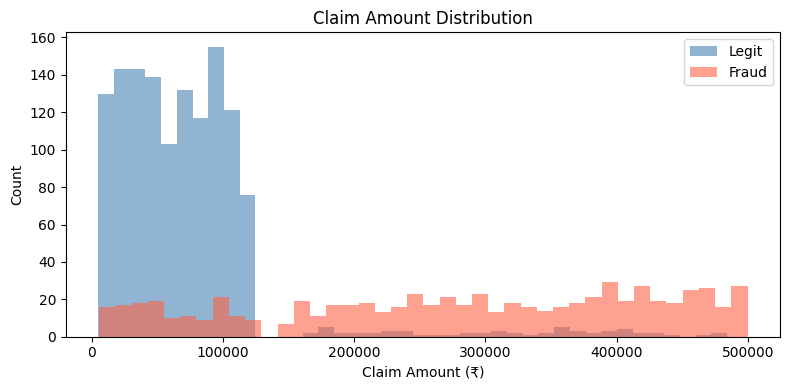

In [7]:
plt.figure(figsize=(8,4))
for label, color in zip([0,1], ['steelblue','tomato']):
    subset = df[df['fraud_label'] == label]['claim_amount']
    plt.hist(subset, bins=40, alpha=0.6, color=color, label='Fraud' if label else 'Legit')
plt.title('Claim Amount Distribution')
plt.xlabel('Claim Amount (₹)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('eda_claim_amount.png')
plt.show()

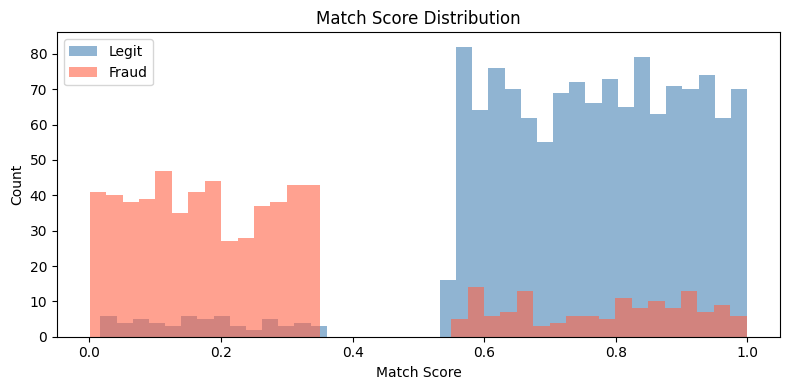

In [8]:
plt.figure(figsize=(8,4))
for label, color in zip([0,1], ['steelblue','tomato']):
    subset = df[df['fraud_label'] == label]['match_score']
    plt.hist(subset, bins=40, alpha=0.6, color=color, label='Fraud' if label else 'Legit')
plt.title('Match Score Distribution')
plt.xlabel('Match Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('eda_match_score.png')
plt.show()

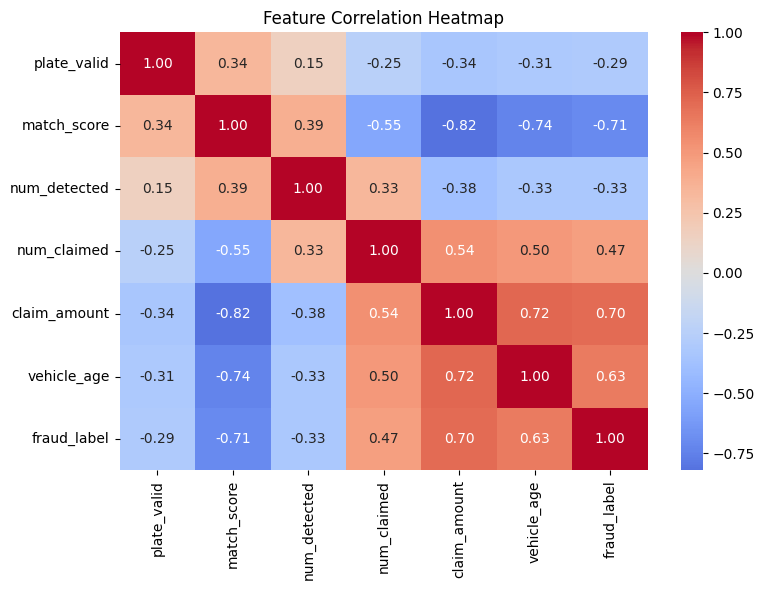

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_heatmap.png')
plt.show()

In [10]:
!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)

In [11]:
df = pd.read_csv('fraud_dataset.csv')

X = df.drop('fraud_label', axis=1)
y = df['fraud_label']

print(X.shape)
print(y.value_counts())

(2000, 6)
fraud_label
0    1318
1     682
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1600, 6)
Test size: (400, 6)


In [13]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)
print("Training done!")

Training done!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:45:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.89      0.96      0.93       264
       Fraud       0.91      0.78      0.84       136

    accuracy                           0.90       400
   macro avg       0.90      0.87      0.88       400
weighted avg       0.90      0.90      0.90       400

AUC-ROC: 0.8518
F1 Score: 0.8379


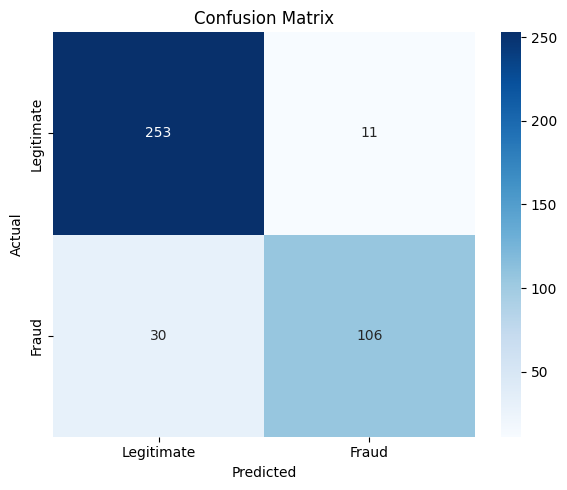

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraud'],
            yticklabels=['Legitimate','Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

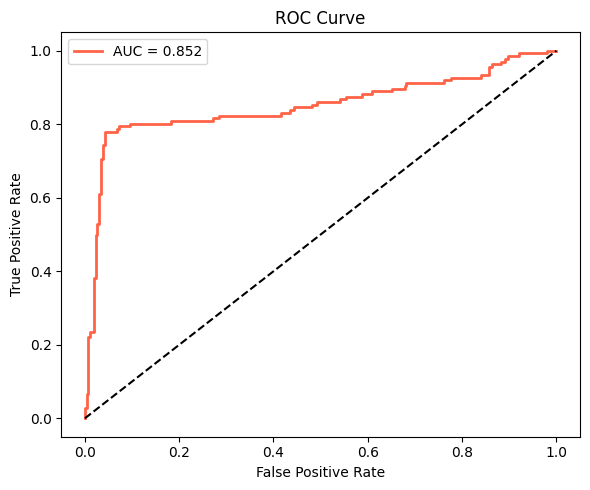

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

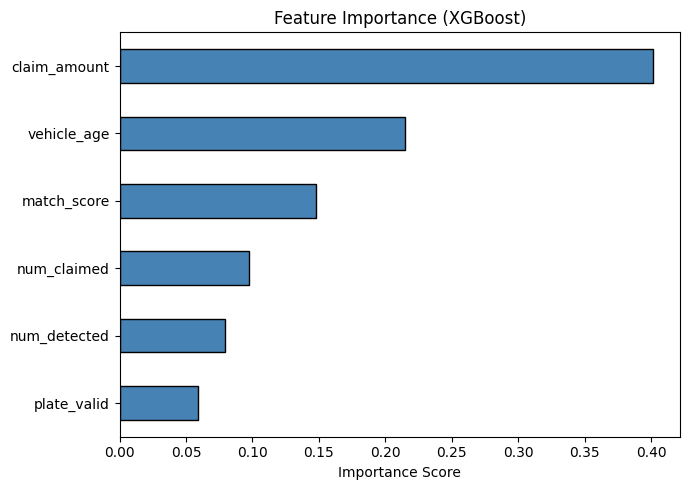

In [17]:
plt.figure(figsize=(7,5))
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

/tmp/ipykernel_2254/21144999.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


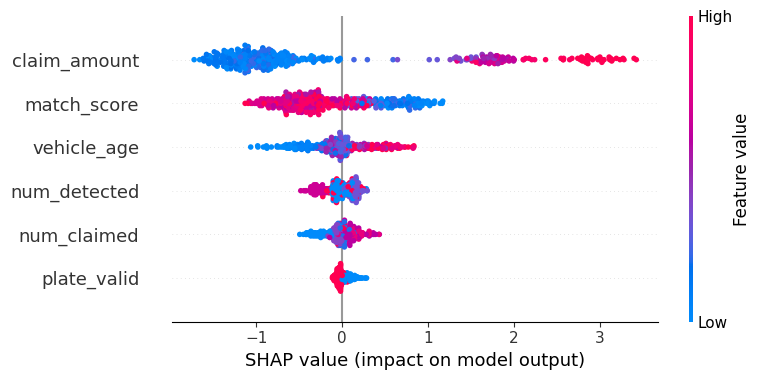

In [18]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

In [19]:
with open('fraud_xgb.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as fraud_xgb.pkl")

Model saved as fraud_xgb.pkl
